# 04. 전처리 Pipeline과 단일·다변수 모델 비교

## tl;dr

- 5-fold CV에서 `age` 단일 모델의 평균 ROC-AUC가 **0.855**로 가장 높았습니다.
- 테스트 ROC-AUC는 나이 단일 모델 **0.858**, 다변수 모델 **0.861**입니다.
- AUC 개선은 **0.0028**이고 bootstrap 95% CI는 약 **[-0.0003, 0.0063]**으로, 사전 기준 0.02를 넘지 못했습니다.
- 따라서 이번 로지스틱 회귀 비교에서는 H0를 기각할 충분한 근거가 없습니다.

## Context & Methods

단일 모델과 다변수 모델 모두 LogisticRegression을 사용하여 알고리즘 차이가 아니라 추가 특성의 정보 이득을 비교합니다.

### Key Assumptions

- 숫자형: median 대치 → 표준화
- `capital-gain/loss`: median 대치 → log1p → 표준화
- 범주형: `Unknown` 대치 → One-Hot Encoding
- 전처리는 각 CV 훈련 fold 안에서만 학습됩니다.
- H0 기각을 위한 실질적 개선 기준은 AUC 0.02 초과입니다.

In [1]:
from pathlib import Path
import contextlib
import io
import sys

import joblib
import pandas as pd
from IPython.display import Image, display

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('adult-marriage-analysis 프로젝트 루트에서 실행하세요.')
sys.path.insert(0, str(project_root))

from src.data import add_target_pandas, ensure_raw_data, load_with_pandas
from src.features import BASE_FEATURES, build_preprocessing_audit
from src.modeling import run_modeling_stage
from src.statistics import split_prepared_data
from src.visualization import (
    create_calibration_chart,
    create_preprocessing_diagnostics,
)

## Data

### 1. 동일한 train/test 분할 재현

In [2]:
raw_path = ensure_raw_data(project_root / 'data' / 'raw')
prepared_df = add_target_pandas(load_with_pandas(raw_path))
train_df, test_df = split_prepared_data(prepared_df)

print('Train:', train_df.shape)
print('Test:', test_df.shape)
print('Base features:', BASE_FEATURES)

Train: (26048, 16)
Test: (6513, 16)
Base features: ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'workclass', 'occupation']


### 2. 전처리 전·후 진단

결측치는 Pipeline 내부 imputer로 제거하고, 0이 아닌 `capital-gain`의 긴 꼬리는 `log1p`로 완화한 뒤 표준화합니다. 차트의 after 값은 대치 단계 직후를 의미합니다.

In [3]:
preprocessing_audit = build_preprocessing_audit(train_df)
preprocessing_audit.to_csv(
    project_root / 'reports' / 'tables' / 'preprocessing_audit.csv',
    index=False,
)
preprocessing_audit

,feature,missing_before,missing_after_imputation,transformation
0,age,0,0,median imputation → StandardScaler
1,education-num,0,0,median imputation → StandardScaler
2,hours-per-week,0,0,median imputation → StandardScaler
3,capital-gain,0,0,median imputation → log1p → StandardScaler
4,capital-loss,0,0,median imputation → log1p → StandardScaler
5,workclass,1506,0,Unknown imputation → OneHotEncoder
6,occupation,1512,0,Unknown imputation → OneHotEncoder


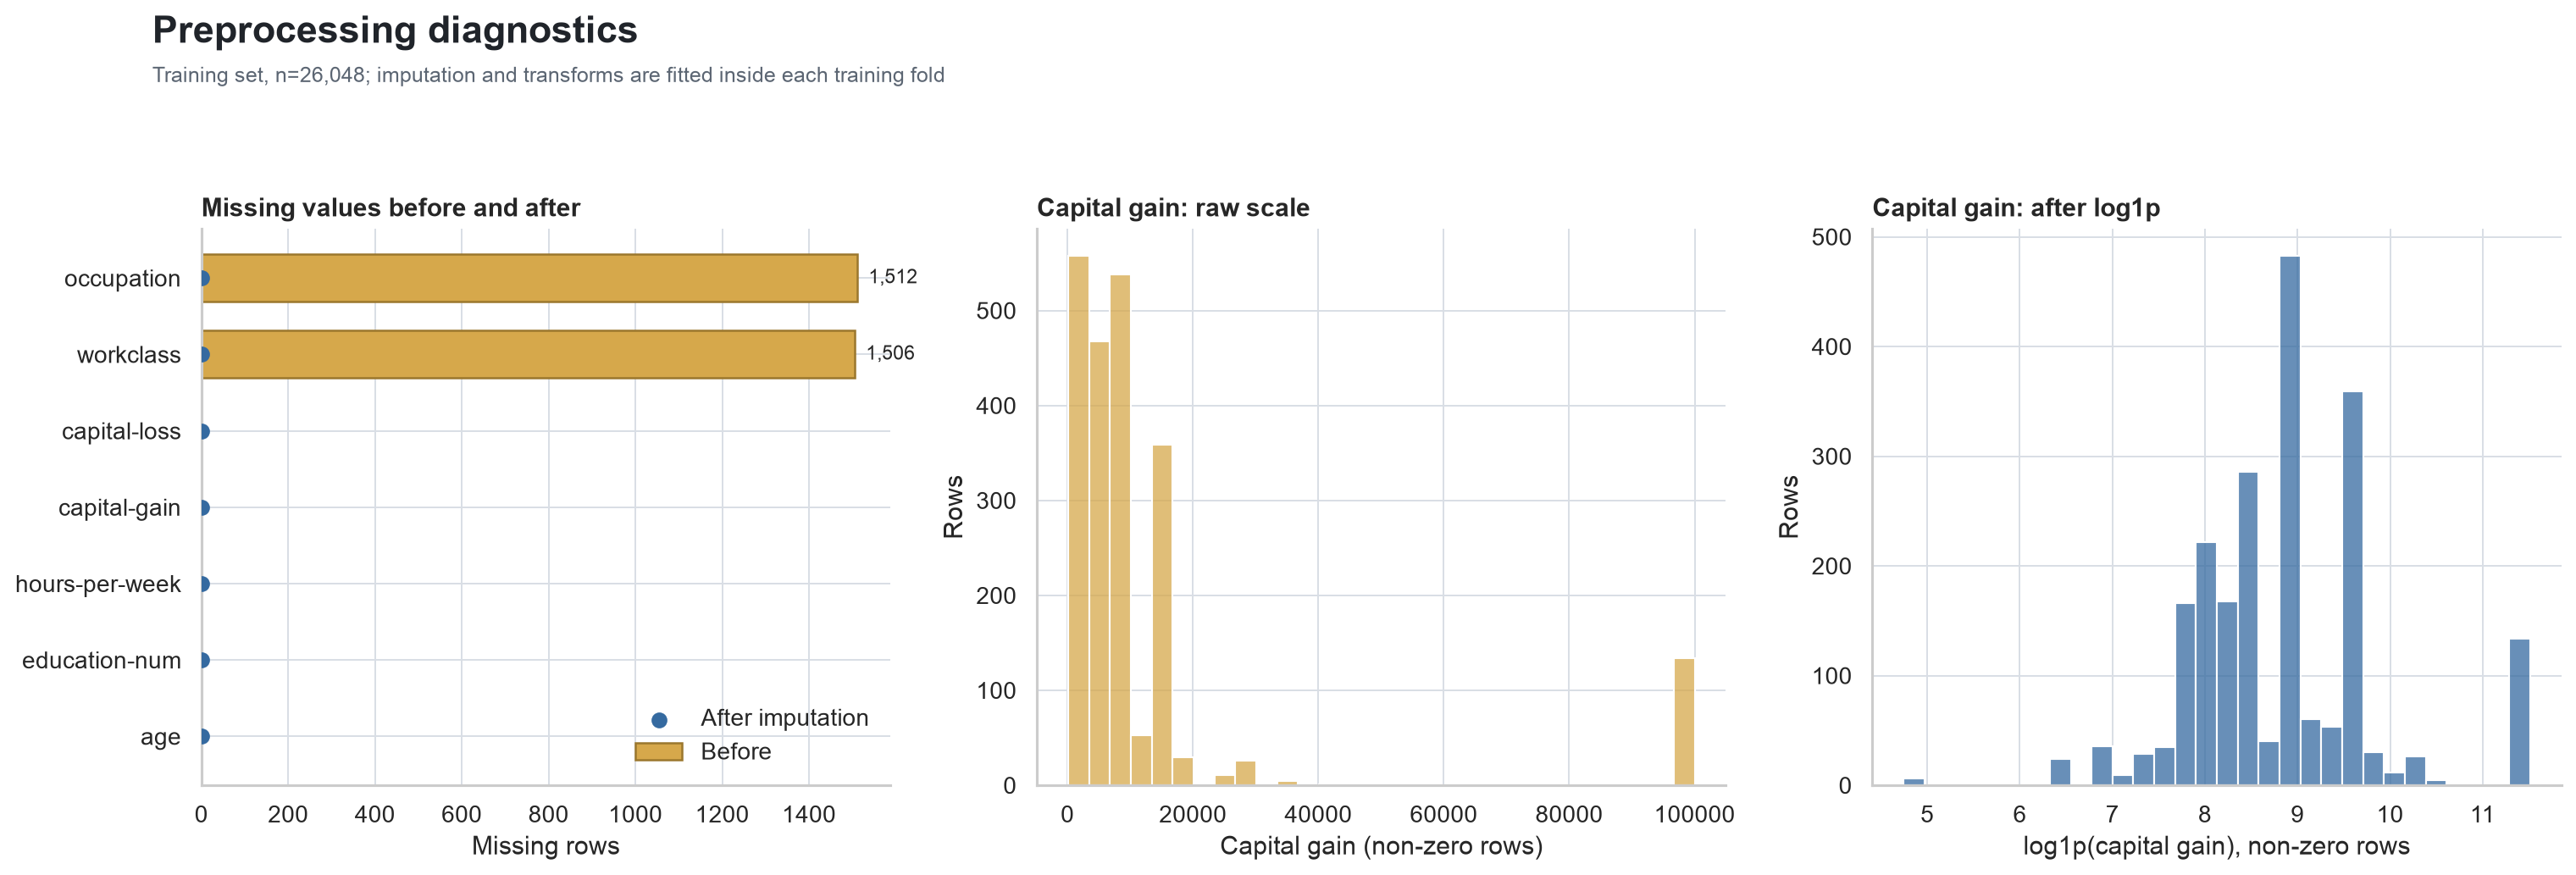

In [4]:
preprocessing_path = create_preprocessing_diagnostics(
    train_df,
    project_root / 'reports' / 'figures' / 'preprocessing_diagnostics.png',
)
display(Image(filename=str(preprocessing_path)))

## Results

### 3. 5-fold 단일 특성 선택과 최종 평가

In [5]:
captured_output = io.StringIO()
with contextlib.redirect_stdout(captured_output):
    modeling = run_modeling_stage(project_root, train_df, test_df)

print('선택된 최적 단일 특성:', modeling.best_feature)
modeling.single_cv.round(4)

선택된 최적 단일 특성: age


,feature,cv_roc_auc_mean,cv_roc_auc_std,cv_brier_mean,cv_brier_std,cv_accuracy_mean,cv_f1_mean
0,age,0.8548,0.0025,0.1383,0.0015,0.8146,0.8652
1,occupation,0.6333,0.0109,0.2095,0.0017,0.6720,0.7935
2,hours-per-week,0.6254,0.0114,0.2110,0.0019,0.6773,0.7979
3,workclass,0.5714,0.0037,0.2153,0.0005,0.6718,0.8037
4,capital-gain,0.5313,0.0041,0.2179,0.0006,0.6719,0.8038
5,education-num,0.5151,0.0127,0.2203,0.0003,0.6719,0.8038
6,capital-loss,0.5132,0.0005,0.2197,0.0001,0.6719,0.8038


### 4. 테스트 성능 비교

In [6]:
modeling.model_metrics.round(4)

,model,accuracy,f1,precision,recall,roc_auc,brier_score
0,best_single_feature,0.8108,0.8616,0.8472,0.8766,0.8577,0.1376
1,multivariable_logistic,0.8124,0.8636,0.8442,0.8839,0.8605,0.1345


Accuracy와 F1은 소폭 개선됐지만, 확률 구분력인 ROC-AUC 개선은 0.0028에 불과합니다. Brier score는 낮을수록 좋으며 다변수 모델에서 0.1376에서 0.1345로 감소했습니다.

### 5. 가설 판단

In [7]:
modeling.hypothesis_result.round(4)

,best_single_feature,single_test_auc,multivariable_test_auc,auc_delta,auc_delta_ci_low,auc_delta_ci_high,practical_auc_margin,exceeds_practical_margin,ci_entirely_above_margin
0,age,0.8577,0.8605,0.0028,-0.0003,0.0063,0.02,False,False


`auc_delta`가 0.02보다 작고 신뢰구간도 0.02를 포함하지 않으므로, 다변수 모델이 실질적으로 더 우수하다는 H1을 지지하지 못합니다. 이는 H0가 참임을 증명한 것이 아니라 H0를 기각할 근거가 부족하다는 의미입니다.

### 6. 로지스틱 계수와 원본 특성 중요도

In [8]:
logistic_coefficients = pd.read_csv(
    project_root / 'reports' / 'tables' / 'logistic_coefficients.csv'
)
logistic_coefficients.head(15).round(4)

,transformed_feature,coefficient,odds_ratio,absolute_coefficient
0,age,1.7532,5.7730,1.7532
1,occupation_Priv-house-serv,-0.7745,0.4609,0.7745
2,occupation_Craft-repair,0.6605,1.9357,0.6605
3,occupation_Transport-moving,0.5352,1.7078,0.5352
4,occupation_Protective-serv,0.5218,1.6851,0.5218
5,workclass_Self-emp-inc,0.4910,1.6339,0.4910
6,occupation_Exec-managerial,0.3758,1.4561,0.3758
7,occupation_Machine-op-inspct,0.3550,1.4261,0.3550
8,workclass_Self-emp-not-inc,0.3114,1.3653,0.3114
9,occupation_Other-service,-0.3068,0.7358,0.3068


In [9]:
permutation_importance = pd.read_csv(
    project_root / 'reports' / 'tables' / 'permutation_importance.csv'
)
permutation_importance.round(4)

,feature,importance_mean,importance_std
0,age,0.3100,0.0057
1,occupation,0.0063,0.0010
2,hours-per-week,0.0048,0.0010
3,education-num,0.0019,0.0006
4,capital-gain,0.0012,0.0005
5,workclass,0.0010,0.0004
6,capital-loss,0.0006,0.0002


Permutation importance에서도 나이를 섞었을 때 AUC가 약 0.310 감소해, 다변수 모델이 사실상 나이에 크게 의존하고 있음을 확인할 수 있습니다.

### 7. 테스트 확률 calibration

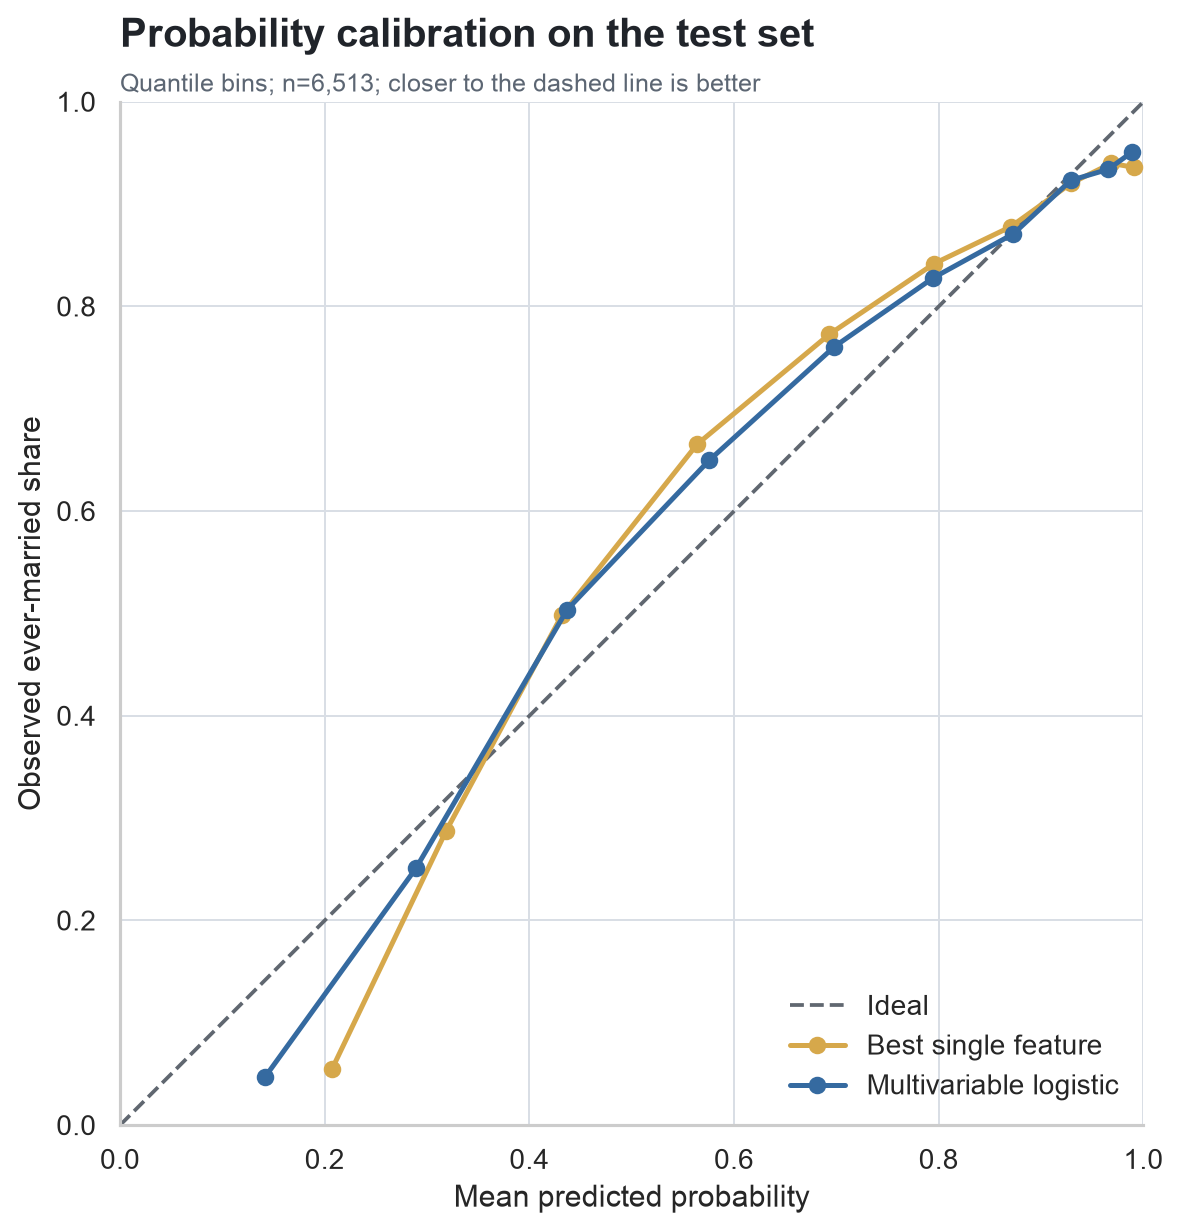

In [10]:
calibration_path = create_calibration_chart(
    modeling.y_test,
    modeling.single_probabilities,
    modeling.multivariable_probabilities,
    project_root / 'reports' / 'figures' / 'calibration_curve.png',
)
display(Image(filename=str(calibration_path)))

### 8. 예시 인물의 혼인 경험 확률 출력

In [11]:
example_person = pd.DataFrame([
    {
        'age': 35,
        'education-num': 13,
        'hours-per-week': 40,
        'capital-gain': 0,
        'capital-loss': 0,
        'workclass': 'Private',
        'occupation': 'Prof-specialty',
    }
])
example_probability = modeling.multivariable_model.predict_proba(
    example_person[BASE_FEATURES]
)[0, 1]

print(f'조사 시점까지 혼인 경험이 있을 추정 확률: {example_probability:.1%}')

조사 시점까지 혼인 경험이 있을 추정 확률: 59.8%


위 값은 1994년 미국 표본에서 유사한 특성을 가진 사람이 조사 시점까지 혼인했을 추정 확률이며, 이 사람의 미래 결혼 확률이 아닙니다.

## Checks

Pipeline, 저장 모델, 확률 범위와 가설 결과를 자동 검증합니다.

In [12]:
single_path = project_root / 'models' / 'single_feature_logistic.joblib'
multi_path = project_root / 'models' / 'multivariable_logistic.joblib'
loaded_model = joblib.load(multi_path)
loaded_probability = loaded_model.predict_proba(example_person[BASE_FEATURES])[0, 1]

assert modeling.best_feature == 'age'
assert single_path.exists() and multi_path.exists()
assert 0 <= example_probability <= 1
assert abs(loaded_probability - example_probability) < 1e-12
assert not bool(modeling.hypothesis_result.loc[0, 'exceeds_practical_margin'])
assert preprocessing_path.exists() and preprocessing_path.stat().st_size > 0
assert calibration_path.exists() and calibration_path.stat().st_size > 0

print('검증 완료: Pipeline, 모델 저장, 확률 출력과 가설 판단이 정상입니다.')

검증 완료: Pipeline, 모델 저장, 확률 출력과 가설 판단이 정상입니다.


## Takeaways

1. `age`가 최적 단일 특성으로 확정됐습니다.
2. 다변수 로지스틱 회귀는 Accuracy·F1·Brier score를 조금 개선했지만 AUC의 실질적 개선 기준을 넘지 못했습니다.
3. 현재 가설 기준에서는 H0를 기각할 충분한 근거가 없습니다.
4. 다음 단계에서는 비선형 모델을 비교해 변수 간 상호작용이 추가 성능을 제공하는지 확인할 수 있습니다.